#### Previo


In [2]:


import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from scipy.interpolate import BSpline as Bspline
from scipy.interpolate import splrep
from scipy.optimize import root_scalar
import uncertainties as unc
import uncertainties.unumpy as unp


def plot_template(title, x_label, y_label, x_lim=None, y_lim=None):
    """Genera la plantilla para mantener consistencia en el formato
    de cada tabla generada.

    Args:
        title (string): Aplica titulos.
        x_label (float): Título de eje x.
        y_label (float): Título de eje y.
        x_lim ([float], optional): Límite en eje x. Defaults to None.
        y_lim ([float], optional): Límite en eje y. Defaults to None.

    Returns:
        object: Devuelve los objetos de la gráfica modificados con la
        plantilla requerida
    """
    fig, ax = plt.subplots(  # Tamaño de la figura en pulgadas (ancho, alto)
        figsize=(10, 6)
    )

    # Configuración de rótulos y unidades
    ax.set_title(title, fontsize=18)  # Título con tamaño de fuente
    ax.set_xlabel(x_label, fontsize=16)  # Eje x con rótulo y unidades
    ax.set_ylabel(y_label, fontsize=16)  # Eje y con rótulo y unidades

    # Configuración de la escala y las dimensiones
    if x_lim is not None:
        ax.set_xlim(x_lim)  # Limitar el eje x
    if y_lim is not None:
        ax.set_ylim(y_lim)  # Limitar el eje y

    ax.grid(True, which="both", linestyle="--", alpha=0.7)  # Añadir una cuadrícula

    fig.tight_layout()  # Ajusta los elementos para que no se solapen

    return (  # Devolver las figuras y ejes para más modificaciones si es necesario
        fig,
        ax,
    )


# test
if False:
    x = np.linspace(0, 10, 100)
    fig, ax = plot_template("This is a test", "X label", "Y label", [0, 10], [-1, 1])
    ax.scatter(x, [np.sin(i) for i in x], marker="+", color="red")

# Práctica #5b: Ley de Malus

_Andrés Felipe Pinzón y Cristian Camilo Pérez_

Universidad Nacional de Colombia

Departamento de Física y Matemáticas


## Tabla de Contenidos

- [Introducción](#introduccion)
- [Modelación Teórica](#modelacion_teorica)
- [Metodología](#metodologia)
- [Análisis y Resultados](#analisis_y_resultados)
- [Conclusiones](#conclusiones)
- [Referencias](#referencias)


## Introducción


## Modelación Teorica


## Metodología


### Esquema experimental


![Esquema](esquema.png)


### Procedimiento Experimental


#### Determinación del tipo de fuente de luz  

Para determinar el tipo de fuente de luz, se empleó únicamente el analizador, inicialmente colocado a 0° y girado hasta 360°. En intervalos de 5°, se midió la intensidad luminosa con el sensor del teléfono celular, registrando el tiempo correspondiente para cada posición.

#### Linealidad del sensor
Dado que la intensidad luminosa es proporcional a:

$$
\begin{align*}
I \propto \cos^2(\theta)
\end{align*}
$$

y dado que la expansión en serie de Taylor alrededor de un punto $\theta_0$ es:

In [3]:

# Definición de variables
x = sp.Symbol('x', real=True)
x0 = sp.Symbol('x0', real=True)

# Función y expansión en serie de Taylor de cos²(x) alrededor de x0
f = sp.cos(x) ** 2
taylor_expansion = sp.series(f, x, x0, 5)  # Expansión hasta orden 4

print(f"La función en LaTeX es: {sp.latex(f)}")
print(f"La expansión en serie en LaTeX es: {sp.latex(taylor_expansion)}")


La función en LaTeX es: \cos^{2}{\left(x \right)}
La expansión en serie en LaTeX es: \cos^{2}{\left(x_{0} \right)} - 2 \left(x - x_{0}\right) \sin{\left(x_{0} \right)} \cos{\left(x_{0} \right)} + \left(x - x_{0}\right)^{2} \left(\frac{\sin^{2}{\left(x_{0} \right)}}{\cos^{2}{\left(x_{0} \right)}} - 1\right) \cos^{2}{\left(x_{0} \right)} + \frac{4 \left(x - x_{0}\right)^{3} \sin{\left(x_{0} \right)} \cos{\left(x_{0} \right)}}{3} + \left(x - x_{0}\right)^{4} \left(- \frac{\sin^{2}{\left(x_{0} \right)}}{3 \cos^{2}{\left(x_{0} \right)}} + \frac{1}{3}\right) \cos^{2}{\left(x_{0} \right)} + O\left(\left(x - x_{0}\right)^{5}; x\rightarrow x_{0}\right)


$$
\begin{align*}
\cos^2\theta &= \cos^{2}{\left(x_{0} \right)} - 2 \left(x - x_{0}\right) \sin{\left(x_{0} \right)} \cos{\left(x_{0} \right)} + \left(x - x_{0}\right)^{2} \left(\frac{\sin^{2}{\left(x_{0} \right)}}{\cos^{2}{\left(x_{0} \right)}} - 1\right) \cos^{2}{\left(x_{0} \right)} + \\
 &\frac{4 \left(x - x_{0}\right)^{3} \sin{\left(x_{0} \right)} \cos{\left(x_{0} \right)}}{3} + \left(x - x_{0}\right)^{4} \left(- \frac{\sin^{2}{\left(x_{0} \right)}}{3 \cos^{2}{\left(x_{0} \right)}} + \frac{1}{3}\right) \cos^{2}{\left(x_{0} \right)} + O\left(\left(x - x_{0}\right)^{5}; x\rightarrow x_{0}\right)
\end{align*}
$$

Por lo que cuando $\theta_0 = \frac{\pi}{4}$ entonces:

$$
\cos^2(\theta)_{\theta_0 = \pi/4} \approx \frac{1}{2} - (\theta - \pi/4) + \frac{2}{3}(\theta - \pi/4)^3
$$

Y para $\theta$ alrededor de $\pi/4$:

$$
\cos^2(\theta) \approx \frac{1}{2} - (\theta - \pi/4)
$$


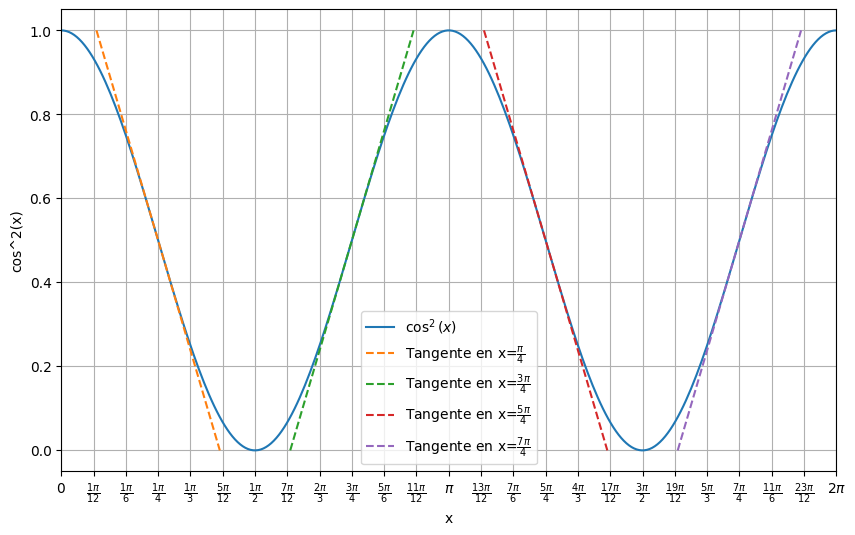

In [2]:
import math
# Graficar cos^2(x) y sus rectas tangentes en los puntos solicitados
xs = np.linspace(0, 2*np.pi, 300)
f_vals = np.cos(xs)**2

puntos = [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4]

plt.figure(figsize=(10, 6))
plt.plot(xs, f_vals, label=fr'$\cos^2(x)$')

latex_simbol = [r'$\frac{\pi}{4}$', r'$\frac{3\pi}{4}$', r'$\frac{5\pi}{4}$', r'$\frac{7\pi}{4}$']
for p in puntos:
    y_p = np.cos(p)**2
    d_p = -2*np.cos(p)*np.sin(p)  # Derivada de cos^2(x)
    # Generar la recta tangente alrededor de p
    t_x = np.linspace(p - 0.5, p + 0.5, 50)
    t_y = y_p + d_p * (t_x - p)
    plt.plot(t_x, t_y, '--', label=rf'Tangente en x={latex_simbol[puntos.index(p)]}')
    plt.xlim(0, 2*np.pi)
    ticks = np.arange(0, 2*np.pi + np.pi/12, np.pi/12)
    labels = []
    for i, val in enumerate(ticks):
        if i == 0:
            labels.append(r"$0$")
        elif i == 24:  # 2π
            labels.append(r"$2\pi$")
        else:
            g = math.gcd(i, 12)
            num = i // g
            den = 12 // g
            if num == 1 and den == 1:
                labels.append(r"$\pi$")
            elif den == 1:
                labels.append(r"$"+f"{num}\\pi"+"$")
            else:
                labels.append(r"$"+f"\\frac{{{num}\\pi}}{{{den}}}"+"$")
    plt.xticks(ticks, labels)
plt.xlabel('x')
plt.ylabel('cos^2(x)')
plt.legend()
plt.grid(True)
plt.show()

Como se puede ver en la anterior figura existe un rango lineal alrededor de cada $\pi/4 + n\pi/2$, en particular entre 20° y 70°, podemos ver la una pequeña desviación, con errores dados por la siguiente gráfica:

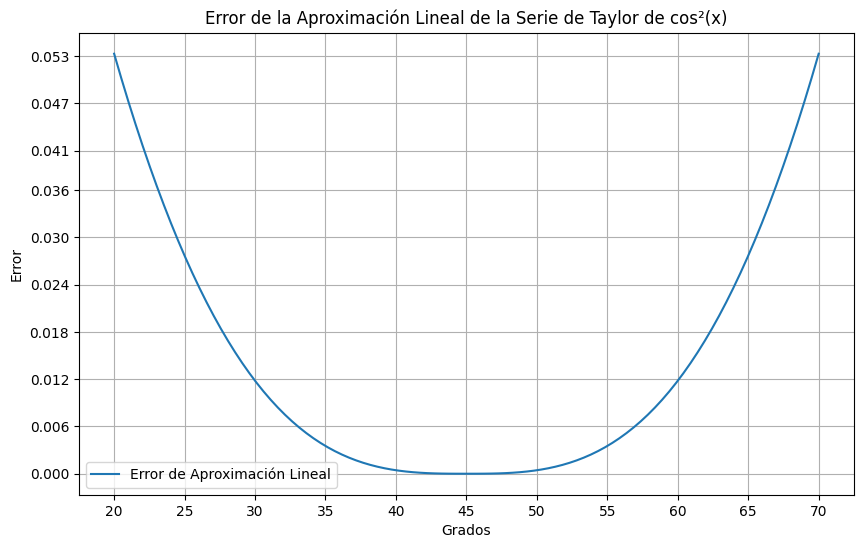

In [4]:
# Definir la función original y la aproximación lineal
def cos2(x):
    return np.cos(x)**2

def taylor_approx(x):
    return 0.5 - (x - np.pi/4)

# Convertir grados a radianes
degrees = np.linspace(20, 70, 100)
radians = np.radians(degrees)

# Calcular el error
error = np.abs(cos2(radians) - taylor_approx(radians))

# Graficar el error
plt.figure(figsize=(10, 6))
plt.plot(degrees, error, label='Error de Aproximación Lineal')
plt.xlabel('Grados')
plt.ylabel('Error')
plt.xticks(np.arange(20, 71, 5))
plt.yticks(np.round(np.linspace(0, max(error), 10), 3))
plt.title('Error de la Aproximación Lineal de la Serie de Taylor de cos²(x)')
plt.grid(True)
plt.legend()
plt.show()

Se observó un error máximo de 5.3×10⁻² (equivalente a 5.3%). Para determinar la linealidad del sensor, se empleó un analizador y un polarizador, ubicando el polarizador a 0° y rotando el analizador de 20° a 70° en pasos de 5°. Se midió la intensidad luminosa con el sensor de un teléfono celular, registrando el tiempo correspondiente para cada posición.


## Análisis y Resultados


### Polarización de la luz de la fuente


### Tratamiento de datos


In [6]:
# Filtrar datos donde "Time (s)" coincide con los valores de tcada5 (dentro de un margen pequeño)
def filtrar_por_tiempos(df, tiempos, margen=0.0015):
    filtro = df["Time (s)"].apply(lambda t: any(abs(t - tiempo) <= margen for tiempo in tiempos))
    return df[filtro]

def remove_repeated_intensities(df):
        return df.drop_duplicates(keep='first')

#### Datos


In [14]:
# Lista de tiempos seleccionados
tcada5 = [
    0,1.86,  2.66,  3.63,  4.66,  5.82,  6.88,  7.87,  8.79, 9.59, 
    10.52, 11.42, 12.45, 13.37, 14.30, 15.24, 16.24, 17.11, 18.08,
    19.02, 19.90, 20.77, 21.68, 22.72, 23.59, 24.51, 25.37, 26.30,
    27.29, 28.14, 29.05, 30.04, 31.12
]

print(len(tcada5))

# Carga de datos desde el archivo xls
datosSensorConAnalizador = pd.read_excel(
    "PolarizacionLinterna/Luz_2025_01_15_16_21_58.xls"
)



# Aplicar filtro
datos_filtrados = filtrar_por_tiempos(datosSensorConAnalizador, tcada5)
datos_filtrados.loc[:, "Time (s)"] = datos_filtrados["Time (s)"].round(2)

datos_filtrados = remove_repeated_intensities(datos_filtrados)

# Mostrar resultados
print(datos_filtrados)

len(datos_filtrados["Illuminance (lx)"])


33
       Time (s)  Illuminance (lx)
0          0.00          2248.625
704        1.86          2255.000
1009       2.66          2248.625
1379       3.63          2242.125
1771       4.66          2248.625
2213       5.82          2248.625
2617       6.88          2261.500
2994       7.87          2274.375
3345       8.79          2287.250
3649       9.59          2306.625
4004      10.52          2325.875
4347      11.42          2358.125
4739      12.45          2377.500
5090      13.37          2403.250
5444      14.30          2416.125
5802      15.24          2441.875
6183      16.24          2461.250
6515      17.11          2487.000
6884      18.08          2487.000
7242      19.02          2512.750
7578      19.90          2519.250
7909      20.77          2525.625
8256      21.68          2525.625
8652      22.72          2512.750
8984      23.59          2499.875
9334      24.51          2487.000
9662      25.37          2480.500
10016     26.30          2448.375
10394     2

33

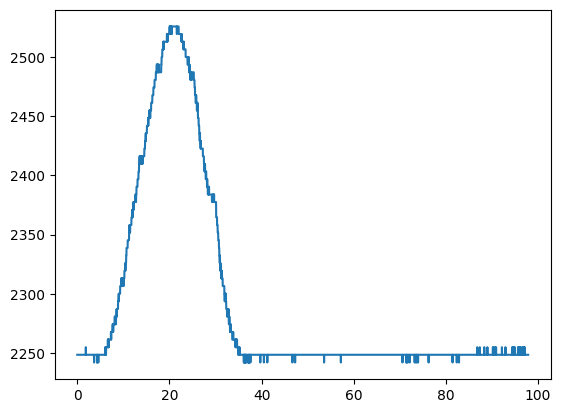

In [17]:
plt.plot(datosSensorConAnalizador["Time (s)"], datosSensorConAnalizador["Illuminance (lx)"], label="Original")

33


Text(0.5, 1.0, 'Distribución de Iluminancia')

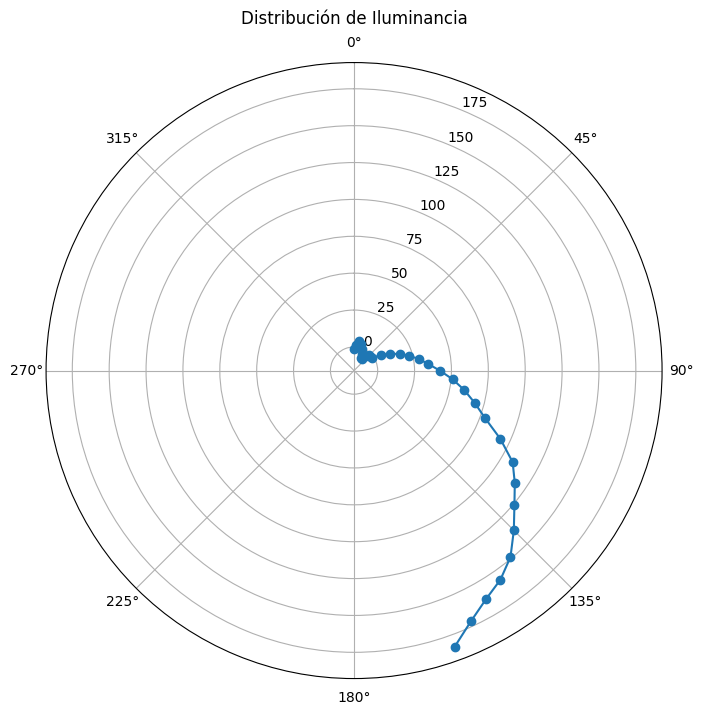

In [26]:
# Obtener las columnas necesarias para la gráfica
iluminancias_filtradas = datos_filtrados["Illuminance (lx)"].values - 2250

# Generar ángulos para la gráfica polar (5 a 160 grados, con 5 grados de separación)
angulos = np.radians(np.arange(0, 165, 5))

print(len(angulos))

# Interpolar las iluminancias al rango de ángulos
iluminancias_interpoladas = np.interp(
    angulos, np.linspace(0, 2 * np.pi, len(iluminancias_filtradas), endpoint=False), iluminancias_filtradas
)

# Graficar en coordenadas polares
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
ax.plot(angulos, iluminancias_interpoladas, marker='o')

# Configurar ejes
ax.set_theta_zero_location("N")  # Norte en la parte superior
ax.set_theta_direction(-1)  # Sentido horario
ax.set_title("Distribución de Iluminancia", va='bottom')

#### Intento 2

In [31]:
tCada10 = [
    0.83, 1.79, 2.61, 3.57, 4.56, 5.62, 6.68, 7.88, 9.09, 10.25, 
    11.26, 12.28, 13.18, 14.07, 14.99, 16.06, 17.62, 18.83, 19.92, 20.91, 
    21.96, 22.99, 24.00, 24.96, 25.86, 26.95, 28.18, 29.34, 30.50, 31.68, 
    32.68, 33.67, 34.68, 35.71, 36.71, 38.36
]

print(len(tCada10))

# Carga de datos desde el archivo xls
datosSensorConAnalizadorIntento2 = pd.read_excel(
    "PolarizacionLinterna/intento2/Luz_2025_01_15_16_34_25.xls"
)


# Aplicar filtro
datos_filtrados2 = filtrar_por_tiempos(datosSensorConAnalizadorIntento2, tCada10,margen=0.002)
datos_filtrados2.loc[:, "Time (s)"] = datos_filtrados2["Time (s)"].round(2)
datos_filtrados2 = remove_repeated_intensities(datos_filtrados2)

# Mostrar resultados
print(datos_filtrados2)

len(datos_filtrados2["Illuminance (lx)"])

36
       Time (s)  Illuminance (lx)
307        0.83          1829.750
673        1.79          1829.750
985        2.61          1836.250
1351       3.57          1829.750
1728       4.56          1849.125
2132       5.62          1874.875
2536       6.68          1907.125
2993       7.88          1971.500
3454       9.09          2042.375
3896      10.25          2087.500
4281      11.26          2119.750
4669      12.28          2132.625
5012      13.18          2132.625
5352      14.07          2113.250
5702      14.99          2081.125
6110      16.06          2036.000
6704      17.62          1958.625
7165      18.83          1907.125
7580      19.92          1874.875
7958      20.91          1849.125
8358      21.96          1829.750
8750      22.99          1829.750
9135      24.00          1842.750
9501      24.96          1874.875
9844      25.86          1913.625
10259     26.95          1971.500
10728     28.18          2036.000
11170     29.34          2081.125
11612     3

36

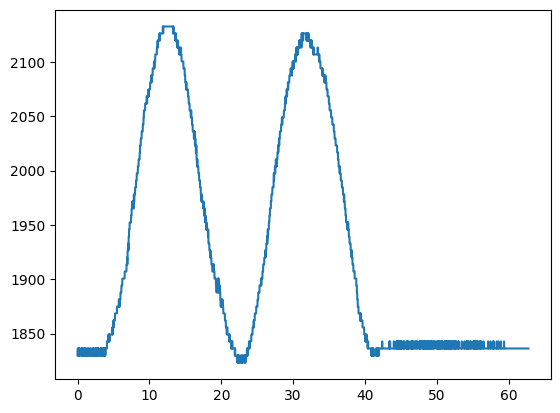

In [28]:
plt.plot(datosSensorConAnalizadorIntento2["Time (s)"], datosSensorConAnalizadorIntento2["Illuminance (lx)"], label="Original")


36


Text(0.5, 1.0, 'Distribución de Iluminancia')

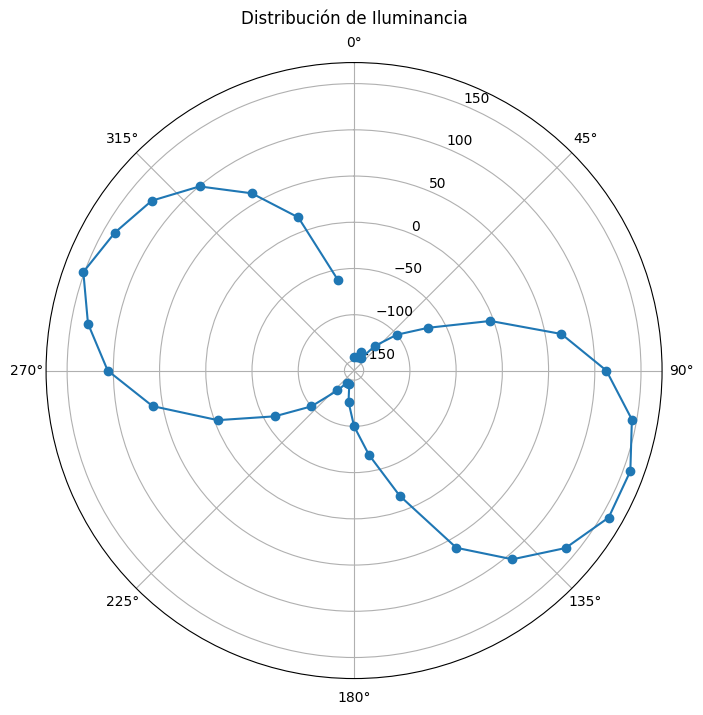

In [33]:
# Obtener las columnas necesarias para la gráfica
iluminancias_filtradas2 = datos_filtrados2["Illuminance (lx)"].values - 1975

# Generar ángulos para la gráfica polar (5 a 160 grados, con 5 grados de separación)
angulos2 = np.radians(np.arange(0, 360, 10))

print(len(angulos2))

# Interpolar las iluminancias al rango de ángulos
iluminancias_interpoladas2 = np.interp(
    angulos2, np.linspace(0, 2 * np.pi, len(iluminancias_filtradas2), endpoint=False), iluminancias_filtradas2
)

# Graficar en coordenadas polares
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
ax.plot(angulos2, iluminancias_interpoladas2, marker='o')

# Configurar ejes
ax.set_theta_zero_location("N")  # Norte en la parte superior
ax.set_theta_direction(-1)  # Sentido horario
ax.set_title("Distribución de Iluminancia", va='bottom')

### Estabilidad fuente de luz

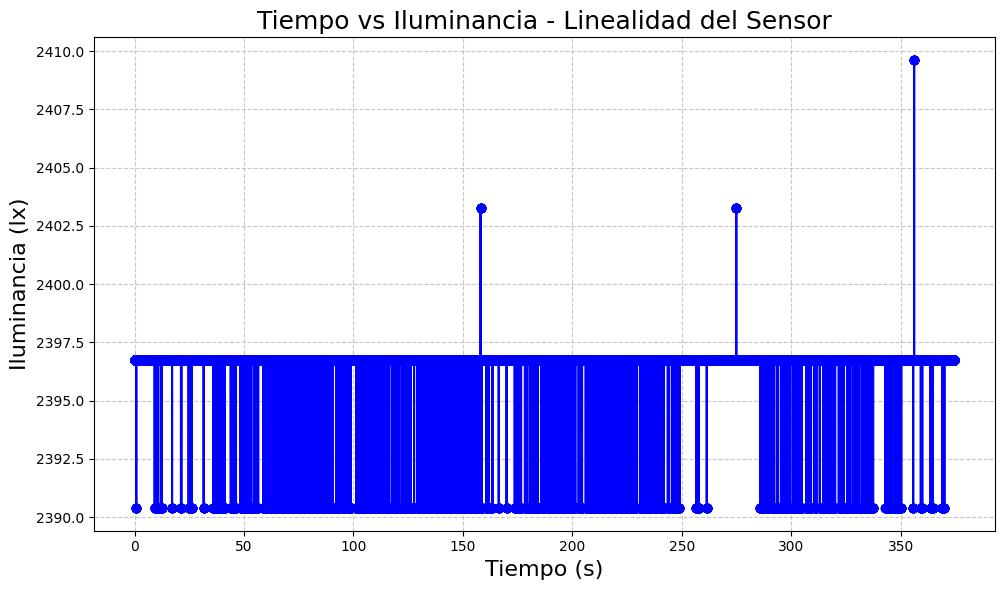

In [56]:
datos_para_estabilidad = pd.read_csv("Estabilidad_fuente/Luz_2025_01_15_16_52_31/Raw_Data.csv",sep = ",")

fig, ax = plot_template("Tiempo vs Iluminancia - Linealidad del Sensor", "Tiempo (s)", "Iluminancia (lx)")
ax.plot(datos_para_estabilidad["Time (s)"][:], datos_para_estabilidad["Illuminance (lx)"][:], marker='o', linestyle='-', color='b')
plt.show()

### Linealidad del sensor 

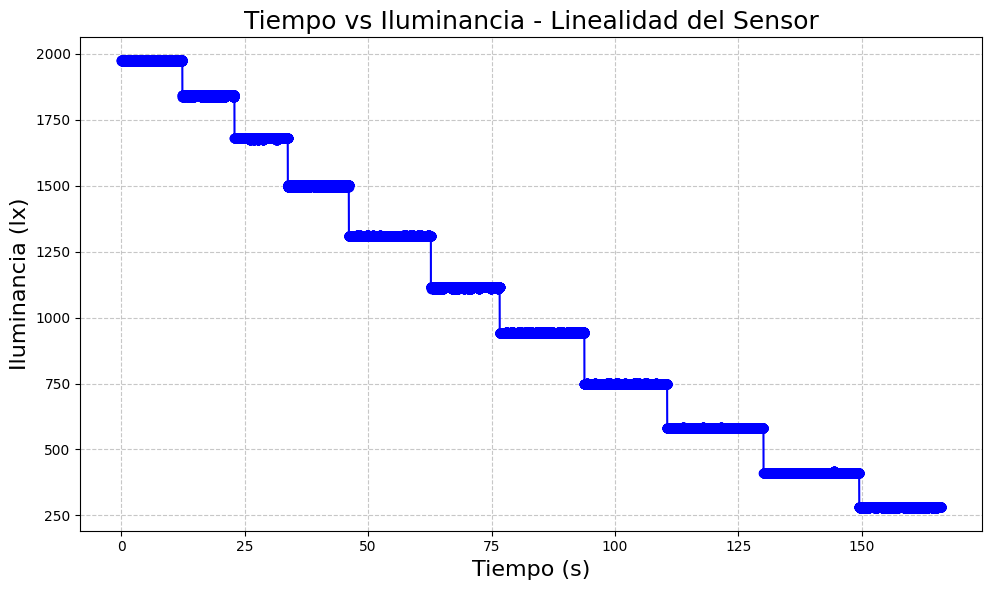

In [51]:
# Cargar datos desde el archivo Excel
datos_linealidad_sensor = pd.read_excel("Linealidad_Sensor/Luz_2025_01_15_17_38_10.xls")


# Graficar tiempo contra iluminancia en coordenadas usuales
fig, ax = plot_template("Tiempo vs Iluminancia - Linealidad del Sensor", "Tiempo (s)", "Iluminancia (lx)")
ax.plot(datos_linealidad_sensor["Time (s)"][:], datos_linealidad_sensor["Illuminance (lx)"][:], marker='o', linestyle='-', color='b')
plt.show()

11


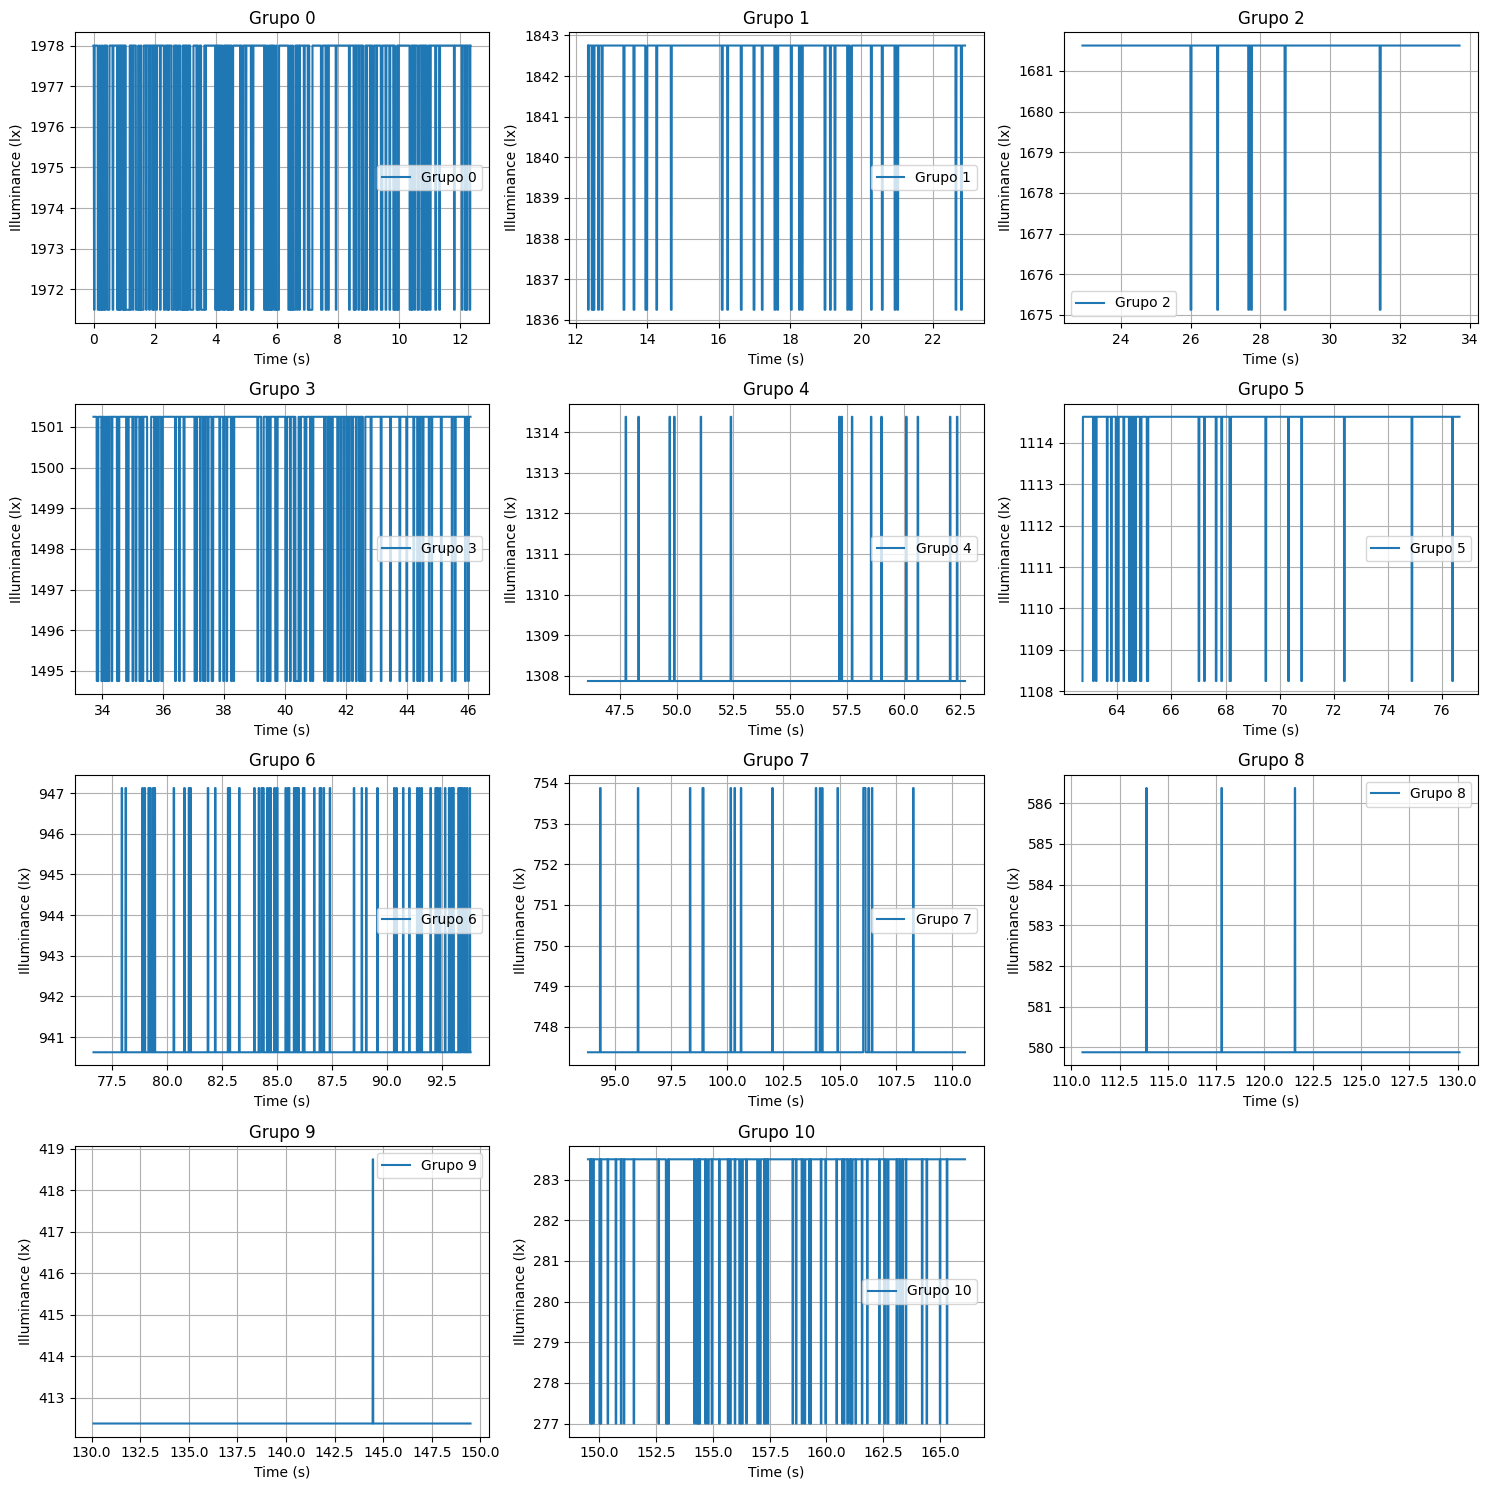

[np.float64(1975.8850085178876), np.float64(1842.244516450648), np.float64(1681.5316682891214), np.float64(1499.9309392265193), np.float64(1308.0248026835043), np.float64(1114.3076324721856), np.float64(941.3144994642583), np.float64(747.5704581049334), np.float64(579.8994854029329), np.float64(412.3827722839339), np.float64(282.7970750988142)]


In [3]:
import pandas as pd

# Cargar los datos desde tu archivo Excel
datos_linealidad_sensor = pd.read_excel("Linealidad_Sensor/Luz_2025_01_15_17_38_10.xls")

# Asegúrate de identificar las columnas correctas. Supongamos que son "Time (s)" e "Illuminance (lx)"
# Ajusta los nombres de las columnas según el archivo Excel.
df = datos_linealidad_sensor[['Time (s)', 'Illuminance (lx)']].copy()

# Definir el umbral para detectar cambios significativos en la iluminancia
umbral_salto = 50  # Ajusta según el comportamiento esperado de tus datos

# Calcular la diferencia absoluta en iluminancia
df['diff_iluminancia'] = df['Illuminance (lx)'].diff().abs()

# Identificar saltos significativos
df['es_salto'] = df['diff_iluminancia'] > umbral_salto

# Asignar un identificador de grupo para cada segmento
df['grupo'] = df['es_salto'].cumsum()

# Dividir los datos en subconjuntos basados en el grupo
grupos = [g for _, g in df.groupby('grupo')]

print(len(grupos))

# # Visualizar los resultados o procesar cada grupo por separado
# for i, grupo in enumerate(grupos):
#     print(f"\n===== Grupo {i} =====")
#     print(grupo[['Time (s)', 'Illuminance (lx)']])
#     # Si necesitas guardar cada grupo como un archivo Excel o CSV:
#     grupo.to_csv(f"grupo_{i}.csv", index=False)


fig, axs = plt.subplots(4, 3, figsize=(15, 15))
axs = axs.flatten()

for i, grupo in enumerate(grupos):
    axs[i].plot(grupo["Time (s)"], grupo["Illuminance (lx)"], label=f"Grupo {i}")
    axs[i].set_title(f"Grupo {i}")
    axs[i].set_xlabel("Time (s)")
    axs[i].set_ylabel("Illuminance (lx)")
    axs[i].legend()
    axs[i].grid(True)

# Eliminar las subfiguras vacías
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


# Calcular el promedio de la intensidad en cada grupo
promedios_intensidad = [grupo['Illuminance (lx)'].mean() for grupo in grupos]

# Mostrar los promedios
print(promedios_intensidad)

[20 25 30 35 40 45 50 55 60 65 70]
Pendiente: -35.20220810524219
Intersección: 2710.089260917239
Coeficiente de correlación: -0.9992647186204208
Valor p: 4.6344509667647306e-14
Error estándar: 0.45022544124293895


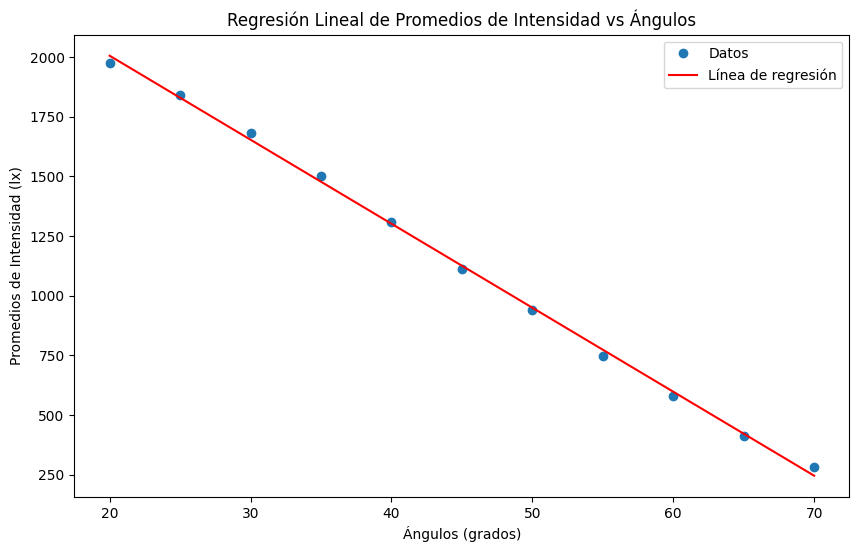

In [8]:
angulos = np.arange(20, 75, 5)
print(angulos)
# Realizar la regresión lineal# Realizar la regresión lineal# Realizar la regresión lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(angulos, promedios_intensidad)

# Mostrar los resultados de la regresión
print(f"Pendiente: {slope}")
print(f"Intersección: {intercept}")
print(f"Coeficiente de correlación: {r_value}")
print(f"Valor p: {p_value}")
print(f"Error estándar: {std_err}")

# Graficar los datos y la línea de regresión
plt.figure(figsize=(10, 6))
plt.plot(angulos, promedios_intensidad, 'o', label='Datos')
plt.plot(angulos, intercept + slope * angulos, 'r', label='Línea de regresión')
plt.xlabel('Ángulos (grados)')
plt.ylabel('Promedios de Intensidad (lx)')
plt.title('Regresión Lineal de Promedios de Intensidad vs Ángulos')
plt.legend()
slope, intercept, r_value, p_value, std_err = stats.linregress(angulos, promedios_intensidad)


## Conclusiones

### 2. Describa el estado de polarización de la luz de la linterna después de pasar por el primer polarizador y después de pasar por el segundo polarizador cuando este último está rotado un ángulo arbitrario entre 0° y 360°.

### 3. Entregue las gr´aficas de sus experimentos en el orden propuesto en la secci´on ”Durante la clase.

### 4. Para la ley de Malus, corrija sus datos en caso de que la respuesta de su detector/c´amara no sea lineal. Compare los gr´aficos que obtuvo para la ley de Malus y discuta las diferencias entre los resultados de: sensor vs c´amara, y, c´amara-regi´on vs c´amara-pixe